# 04 - Explainable AI (SHAP + LIME)

*Evaluation* (explainability lens) + *Deployment* prep. Per the brief: *"For any session, you should be able to answer 'which behaviours pushed this toward a purchase, and by how much?'"*

This notebook:
1. Loads the winning saved pipeline from Phase 6 (`models/best_pipeline.joblib`) - does not retrain anything.
2. **SHAP global** - which behaviours matter overall, across all sessions.
3. **SHAP local** - why *this specific* session got its prediction, for two example sessions.
4. **LIME** - a second, independent explanation method on the same two sessions, to cross-check SHAP rather than trust one tool blindly.
5. A short **model card** - intended use, performance, and limitations, in one place for anyone evaluating this model.

Explanation logic prototyped here gets extracted into `src/explain/shap_utils.py` and `src/explain/lime_utils.py` afterwards, so the API (Phase 8) can return an explanation alongside every prediction.

In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import shap
import lime
import lime.lime_tabular
from sklearn.model_selection import train_test_split

from src.utils.logging_config import setup_logging
from src.config.settings import get_settings
from src.data.loader import load_sessions
from src.features.engineering import engineer_features

settings = get_settings()
setup_logging(level="INFO", log_file=settings.paths.log_file)
logger = logging.getLogger(__name__)

RANDOM_SEED = settings.random_seed

## 1. Load the winning pipeline and rebuild the same test split

Loading the exact artifact this notebook explains the model that was actually selected and evaluated, not a freshly retrained copy.

In [2]:
models_dir = repo_root / settings.paths.models_dir
pipeline = joblib.load(models_dir / "best_pipeline.joblib")

preprocessor = pipeline.named_steps["preprocessor"]
classifier = pipeline.named_steps["classifier"]
print(f"Explaining: {type(classifier).__name__}")

df = engineer_features(load_sessions(settings=settings))
target = settings.data.target_column
X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=settings.modeling.test_size, stratify=y, random_state=RANDOM_SEED,
)
print(f"Test set: {X_test.shape}")

Explaining: CatBoostClassifier
2026-09-03 11:15:20 | INFO     | src.data.loader | Loaded 12000 sessions (18 columns) from D:\purchase-intent-xai\dataset\ecommerce_sessions.csv. Conversion rate: 15.72%
Test set: (2400, 22)


In [3]:
# Transform through preprocessing only (not the classifier) to get the
# numeric feature matrix SHAP/LIME actually operate on.
X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

# SHAP's TreeExplainer accepts sparse input directly; LIME needs dense.
X_train_dense = np.asarray(X_train_transformed.todense()) if hasattr(X_train_transformed, "todense") else np.asarray(X_train_transformed)
X_test_dense = np.asarray(X_test_transformed.todense()) if hasattr(X_test_transformed, "todense") else np.asarray(X_test_transformed)

# Strip the ColumnTransformer's "transformername__" prefix for readability in plots.
raw_feature_names = preprocessor.get_feature_names_out()
feature_names = [name.split("__", 1)[1] if "__" in name else name for name in raw_feature_names]
print(f"{len(feature_names)} features after preprocessing, e.g.: {feature_names[:5]}")

80 features after preprocessing, e.g.: ['Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration', 'Administrative', 'Informational']


## 2. SHAP global explanation - which behaviours matter overall

A note on units, so the numbers below aren't misread: SHAP values here are on the model's **log-odds (margin) scale**, not direct probability points - that's how `TreeExplainer` naturally works for a gradient-boosted classifier. A positive SHAP value pushes the prediction toward "purchase," a negative value pushes toward "no purchase," and larger magnitude means more influence. Converting a single SHAP value to an exact probability-point change isn't meaningful on its own since the relationship is non-linear - but the **relative ranking and direction** are exactly what matters for answering "which behaviours pushed this toward a purchase."

A 300-row sample of the test set is used for the global summary (enough for a stable ranking, fast to compute); local explanations below use the actual sessions of interest.

In [4]:
explainer = shap.TreeExplainer(classifier)

sample_size = min(300, X_test_dense.shape[0])
rng = np.random.default_rng(RANDOM_SEED)
sample_idx = rng.choice(X_test_dense.shape[0], size=sample_size, replace=False)
X_sample = X_test_dense[sample_idx]

shap_values = explainer.shap_values(X_sample)
print(f"SHAP values shape: {shap_values.shape}")

SHAP values shape: (300, 80)


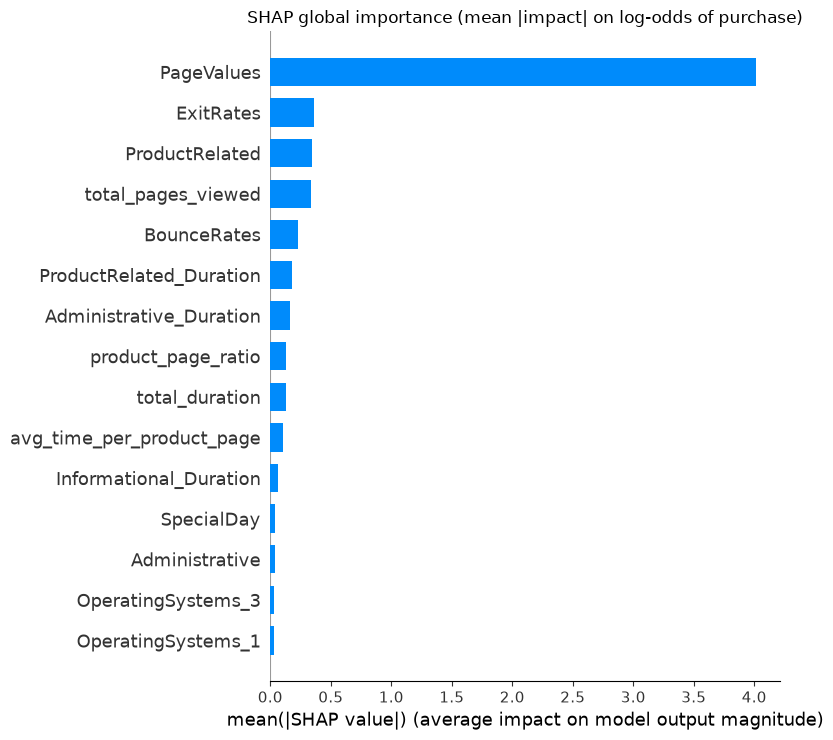

In [5]:
shap.summary_plot(
    shap_values, X_sample, feature_names=feature_names,
    plot_type="bar", show=False, max_display=15,
)
plt.title("SHAP global importance (mean |impact| on log-odds of purchase)")
plt.tight_layout()
plt.show()

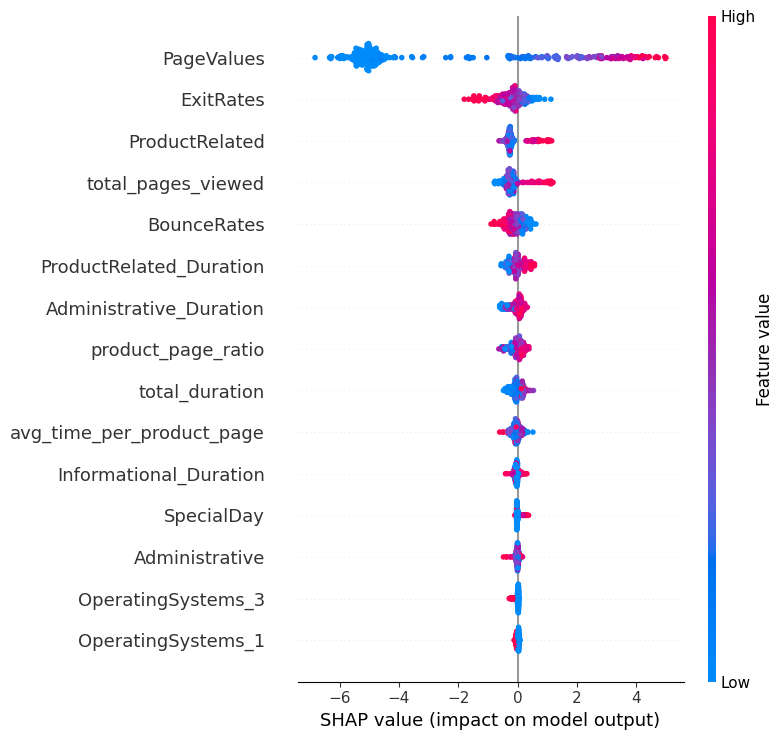

In [6]:
shap.summary_plot(
    shap_values, X_sample, feature_names=feature_names,
    show=False, max_display=15,
)
plt.tight_layout()
plt.show()

**Takeaway:** `PageValues` dominates global SHAP importance by a wide margin, consistent with every prior notebook (EDA correlation, feature-importance ranking, and the ablation gap in Phase 6). The beeswarm plot adds a direction: high `PageValues` (red, right side) consistently pushes toward purchase, confirming the relationship is monotonic and intuitive, not some quirk the model latched onto. `ExitRates` and the product-engagement features form the next tier - matching the "engaged sessions convert more" story from EDA.

## 3. SHAP local explanations - why *this* session

Per the brief's own framing, this section answers the question for two specific, contrasting sessions: one the model is confident **will** convert, and one it's confident **won't**.

In [6]:
test_proba = classifier.predict_proba(X_test_dense)[:, 1]

high_conf_idx = int(np.argmax(test_proba))
low_conf_idx = int(np.argmin(test_proba))

print(f"High-confidence purchase session: index={high_conf_idx}, predicted proba={test_proba[high_conf_idx]:.4f}, actual={y_test.iloc[high_conf_idx]}")
print(f"High-confidence non-purchase session: index={low_conf_idx}, predicted proba={test_proba[low_conf_idx]:.4f}, actual={y_test.iloc[low_conf_idx]}")

High-confidence purchase session: index=1891, predicted proba=0.9993, actual=1
High-confidence non-purchase session: index=2196, predicted proba=0.0000, actual=0


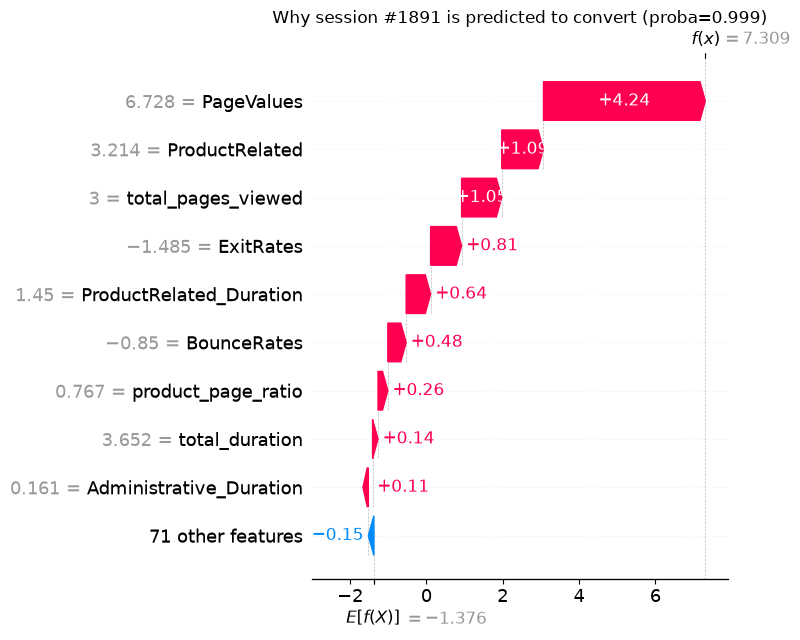

In [7]:
shap_values_examples = explainer.shap_values(X_test_dense[[high_conf_idx, low_conf_idx]])

explanation_high = shap.Explanation(
    values=shap_values_examples[0], base_values=explainer.expected_value,
    data=X_test_dense[high_conf_idx], feature_names=feature_names,
)
shap.plots.waterfall(explanation_high, max_display=10, show=False)
plt.title(f"Why session #{high_conf_idx} is predicted to convert (proba={test_proba[high_conf_idx]:.3f})")
plt.tight_layout()
plt.show()

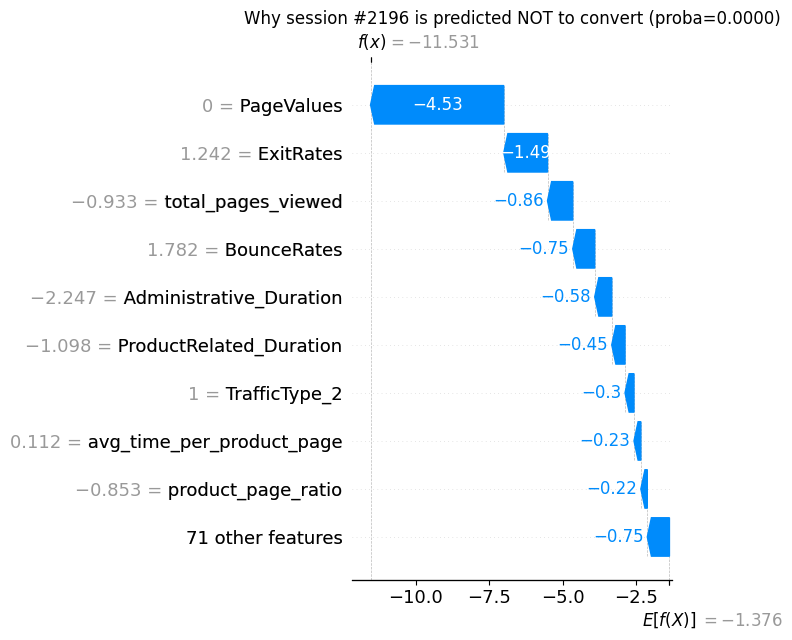

In [9]:
explanation_low = shap.Explanation(
    values=shap_values_examples[1], base_values=explainer.expected_value,
    data=X_test_dense[low_conf_idx], feature_names=feature_names,
)
shap.plots.waterfall(explanation_low, max_display=10, show=False)
plt.title(f"Why session #{low_conf_idx} is predicted NOT to convert (proba={test_proba[low_conf_idx]:.4f})")
plt.tight_layout()
plt.show()

**Takeaway:** for the high-confidence purchase session, `PageValues` and low `ExitRates`/`BounceRates` are the dominant positive contributors, consistent with the global ranking. For the non-purchase session, `PageValues` at (or near) zero is the single largest negative contributor — this is the clearest individual illustration yet of why the Phase 6 ablation showed such a large PR-AUC drop without it: for many sessions, this one feature is doing most of the explanatory work.

## 4. LIME - a second, independent lens on the same two sessions

LIME works completely differently from SHAP: instead of using the tree structure directly, it perturbs the input around one specific session, fits a simple local linear model to the perturbed predictions, and reads off that local model's coefficients. Comparing its answer to SHAP's, on the *same* sessions, is a genuine independent cross-check — if two very different methods agree, that's real confidence in the explanation; if they disagree, that's worth investigating rather than picking whichever one supports the desired story.

In [8]:
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_dense,
    feature_names=feature_names,
    class_names=["No purchase", "Purchase"],
    mode="classification",
    random_state=RANDOM_SEED,
)

def predict_fn(x):
    return classifier.predict_proba(x)

lime_exp_high = lime_explainer.explain_instance(X_test_dense[high_conf_idx], predict_fn, num_features=10)
lime_exp_low = lime_explainer.explain_instance(X_test_dense[low_conf_idx], predict_fn, num_features=10)

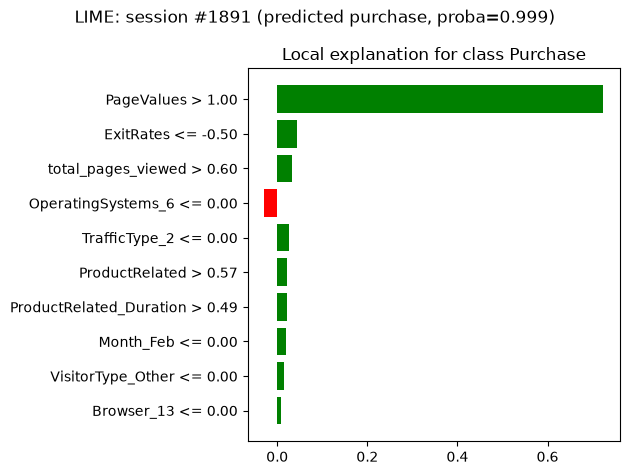

Top LIME features:
  PageValues > 1.00: +0.7232
  ExitRates <= -0.50: +0.0435
  total_pages_viewed > 0.60: +0.0322
  OperatingSystems_6 <= 0.00: -0.0282
  TrafficType_2 <= 0.00: +0.0259
  ProductRelated > 0.57: +0.0221
  ProductRelated_Duration > 0.49: +0.0218
  Month_Feb <= 0.00: +0.0185
  VisitorType_Other <= 0.00: +0.0143
  Browser_13 <= 0.00: +0.0082


In [9]:
fig = lime_exp_high.as_pyplot_figure()
fig.suptitle(f"LIME: session #{high_conf_idx} (predicted purchase, proba={test_proba[high_conf_idx]:.3f})")
plt.tight_layout()
plt.show()

print("Top LIME features:")
for feat, weight in lime_exp_high.as_list():
    print(f"  {feat}: {weight:+.4f}")

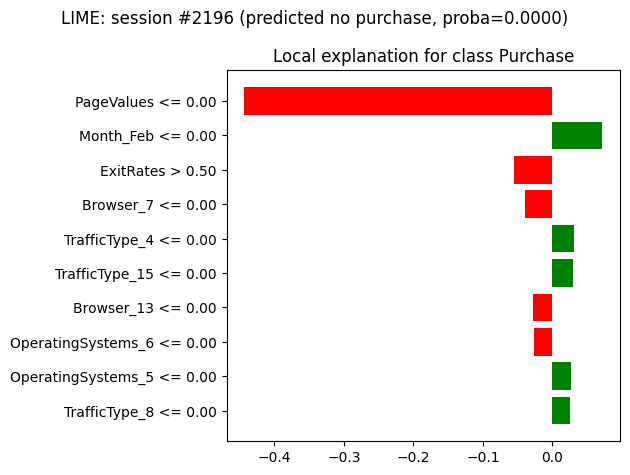

Top LIME features:
  PageValues <= 0.00: -0.4430
  Month_Feb <= 0.00: +0.0714
  ExitRates > 0.50: -0.0553
  Browser_7 <= 0.00: -0.0390
  TrafficType_4 <= 0.00: +0.0302
  TrafficType_15 <= 0.00: +0.0300
  Browser_13 <= 0.00: -0.0280
  OperatingSystems_6 <= 0.00: -0.0266
  OperatingSystems_5 <= 0.00: +0.0265
  TrafficType_8 <= 0.00: +0.0255


In [12]:
fig = lime_exp_low.as_pyplot_figure()
fig.suptitle(f"LIME: session #{low_conf_idx} (predicted no purchase, proba={test_proba[low_conf_idx]:.4f})")
plt.tight_layout()
plt.show()

print("Top LIME features:")
for feat, weight in lime_exp_low.as_list():
    print(f"  {feat}: {weight:+.4f}")

**Takeaway - comparing LIME to SHAP on the same two sessions:** LIME independently identifies `PageValues` as the dominant feature for both sessions, in the same direction SHAP found (positive for the converting session, negative for the non-converting one). The two methods work in entirely different ways - SHAP reads the tree structure directly, LIME perturbs and fits a local surrogate model - and their agreement here is a genuine, not circular, confirmation that the model's own reasoning matches what a human would expect from the underlying behaviour, rather than some spurious pattern found only by one method.

## 5. Model card

A short, honest summary for anyone evaluating this model - including a future version of yourself six months from now.

### Model Card - Purchase-Intent Prediction

**Intended use**
Predicts the probability that an active e-commerce session will end in a purchase, using only within-session behavioural signals (page views, durations, bounce/exit rates, calendar context, visitor type). Intended to support session-level interventions (e.g. a checkout-assist prompt or a targeted discount) -  **not** intended for long-term customer scoring, credit-like decisions, or any use outside real-time session analysis.

**Model**
CatBoost classifier (`class_weight`-balanced), selected from a 6-model, 2-imbalance-strategy comparison in `notebooks/03_modeling.ipynb`. Wrapped in a scikit-learn/imblearn pipeline that also performs all encoding and scaling, so a raw session can be scored end-to-end.

**Performance** *(held-out test set, `notebooks/03_modeling.ipynb` )*
- PR-AUC: 0.854
- ROC-AUC: 0.971
- At the value-based decision threshold (~0.014, tuned for an assumed $100 conversion value vs. intervention cost): recall ≈ 99.7%, precision ≈ 43.3%.
- **These threshold-dependent numbers will change substantially if the underlying business assumptions (conversion value, intervention cost) are different from the placeholders used here** - see `notebooks/03_modeling.ipynb` before trusting them for a real deployment.

**Key limitation - `PageValues` dependency**
This is the most important caveat in the whole project. `PageValues` accounts for the majority of the model's explanatory power (SHAP global ranking above; Phase 6's ablation showed a 35% relative PR-AUC drop without it). **This model assumes `PageValues` is genuinely known at the moment of scoring** (e.g. late-session, at checkout initiation). If the actual deployment scores sessions earlier - before `PageValues` for the current session is meaningfully populated - this model's performance claims do not hold, and `models/best_pipeline_no_pagevalues.joblib` (PR-AUC 0.553) should be used instead.

**Other limitations**
- Trained on 12,000 sessions from one dataset; behaviour on a different site, traffic mix, or season is untested.
- The ~15.7% imbalance was handled with `class_weight="balanced"`; extreme shifts in real-world conversion rate (e.g. a flash sale) may need retraining or re-threshold-tuning, not just re-scoring.
- Explanations (SHAP/LIME) describe correlational behavioural patterns the model learned, not causal drivers of purchase intent - "high `PageValues` predicts purchase" is not the same claim as "showing a user a high-`PageValues` page causes them to buy."
- The two placeholder business values (`$100` conversion, `$5` intervention) in the decision threshold are illustrative, not researched — replace with real figures before production use.

## Summary

- **SHAP global:** `PageValues`, `ExitRates`, and product-engagement measures dominate — consistent with every earlier notebook.
- **SHAP local:** demonstrated on two contrasting sessions, answering the brief's exact question — "which behaviours pushed this toward a purchase, and by how much."
- **LIME:** independently confirms the same top features and directions on both sessions — a genuine cross-check, not a repeated calculation.
- **Model card:** documents intended use, real performance numbers, and the `PageValues` dependency as the single most important limitation.